# Mô tả bộ dữ liệu
***Oxford Parkinson's Disease Telemonitoring Dataset***  
Subject of dataset: `Accurate Telemonitoring of Parkinson's Disease Progression by Noninvasive Speech Tests`  

This dataset is composed of a range of biomedical voice measurements from `42 people with early-stage Parkinson's disease recruited to a six-month trial of a telemonitoring device for remote symptom progression monitoring.` The recordings were automatically captured in the patient's homes.

Columns in the table contain subject number, subject age, subject gender, time interval from baseline recruitment date, motor UPDRS, total UPDRS, and 16 biomedical voice measures. Each row corresponds to one of `5,875 voice recording from these individuals`. The main aim of the data is to predict the motor and total UPDRS scores `('motor_UPDRS' and 'total_UPDRS')` from the **16 voice measures**.

Further details are contained [This Site](https://archive.ics.uci.edu/dataset/189/parkinsons+telemonitoring).

---

**Features of Dataset:**  
`subject#` - Integer that uniquely identifies each subject

`age` - Subject age

`sex` - Subject gender '0' - male, '1' - female

`test_time` - Time since recruitment into the trial. The integer part is the number of days since recruitment.

`motor_UPDRS` - Clinician's motor UPDRS score, linearly interpolated

`total_UPDRS` - Clinician's total UPDRS score, linearly interpolated

`Jitter(%)`,`Jitter(Abs)`,`Jitter:RAP`,`Jitter:PPQ5`,`Jitter:DDP` - Several measures of variation in fundamental frequency

`Shimmer`,`Shimmer(dB)`,`Shimmer:APQ3`,`Shimmer:APQ5`,`Shimmer:APQ11`,`Shimmer:DDA` - Several measures of variation in amplitude

`NHR`,`HNR` - Two measures of ratio of noise to tonal components in the voice

`RPDE` - A nonlinear dynamical complexity measure

`DFA` - Signal fractal scaling exponent

`PPE` - A nonlinear measure of fundamental frequency variation  

# Phân tích và tiền xử lí dữ liệu

- Trong phần này, chúng ta sẽ phân tích các đặc trưng của bộ dữ liệu, từ đó đưa ra phương pháp hợp lí để xử lý dữ liệu, giúp mô hình có thể học tốt hơn. Cụ thể, với bộ dữ liệu này, ngoài một số thông tin cơ bản, chúng ta sẽ kiểm tra và xử lý:

    - Data duplication
    - Missing values
    - Outliers
    - Features correlation
    - Data imbalance (Optional?)


In [112]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
try:
    from ucimlrepo import fetch_ucirepo
except:
    print("ucimlrepo package not found. Please install it using 'pip install ucimlrepo' to fetch datasets from the UCI repository.")
    %pip install ucimlrepo
    from ucimlrepo import fetch_ucirepo

In [113]:
raw_dataset = fetch_ucirepo(id=189)
X = raw_dataset.data.features
y = raw_dataset.data.targets
df = pd.concat([X, y], axis=1)
df.head()
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5875, 21)


,age,test_time,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,Shimmer,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE,sex,motor_UPDRS,total_UPDRS
0,72,5.6431,0.00662,0.000034,0.00401,0.00317,0.01204,0.02565,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006,0,28.199,34.398
1,72,12.6660,0.00300,0.000017,0.00132,0.00150,0.00395,0.02024,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810,0,28.447,34.894
2,72,19.6810,0.00481,0.000025,0.00205,0.00208,0.00616,0.01675,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014,0,28.695,35.389
3,72,25.6470,0.00528,0.000027,0.00191,0.00264,0.00573,0.02309,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277,0,28.905,35.810
4,72,33.6420,0.00335,0.000020,0.00093,0.00130,0.00278,0.01703,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361,0,29.187,36.375


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5875 entries, 0 to 5874
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            5875 non-null   int64  
 1   test_time      5875 non-null   float64
 2   Jitter(%)      5875 non-null   float64
 3   Jitter(Abs)    5875 non-null   float64
 4   Jitter:RAP     5875 non-null   float64
 5   Jitter:PPQ5    5875 non-null   float64
 6   Jitter:DDP     5875 non-null   float64
 7   Shimmer        5875 non-null   float64
 8   Shimmer(dB)    5875 non-null   float64
 9   Shimmer:APQ3   5875 non-null   float64
 10  Shimmer:APQ5   5875 non-null   float64
 11  Shimmer:APQ11  5875 non-null   float64
 12  Shimmer:DDA    5875 non-null   float64
 13  NHR            5875 non-null   float64
 14  HNR            5875 non-null   float64
 15  RPDE           5875 non-null   float64
 16  DFA            5875 non-null   float64
 17  PPE            5875 non-null   float64
 18  sex     

+ Qua hàm df.info(), ta biết được một số thông tin sau:
    + Dữ liệu có 22 đặc trưng với 5875 mẫu. Trong đó, motor_UPDRS và total_UPDRS là biến mục tiêu.
    + Tất cả dữ liệu đều ở dạng số thực hoặc số nguyên.
    + Bộ dữ liệu không có dữ liệu bị thiếu.

Tiếp theo, chúng ta sẽ kiểm tra dữ liệu trùng lặp.

In [115]:
print(f'Number of duplicated rows: {df.duplicated().sum()}')
target = ['motor_UPDRS', 'total_UPDRS']
features = [col for col in df.columns if col not in target]
print(f'Number of duplicated features rows: {df[features].duplicated().sum()}')

Number of duplicated rows: 0
Number of duplicated features rows: 0


In [116]:
df.describe()

,age,test_time,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,Shimmer,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE,sex,motor_UPDRS,total_UPDRS
count,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000
mean,64.804936,92.863722,0.006154,0.000044,0.002987,0.003277,0.008962,0.034035,0.310960,0.017156,0.020144,0.027481,0.051467,0.032120,21.679495,0.541473,0.653240,0.219589,0.317787,21.296229,29.018942
std,8.821524,53.445602,0.005624,0.000036,0.003124,0.003732,0.009371,0.025835,0.230254,0.013237,0.016664,0.019986,0.039711,0.059692,4.291096,0.100986,0.070902,0.091498,0.465656,8.129282,10.700283
min,36.000000,-4.262500,0.000830,0.000002,0.000330,0.000430,0.000980,0.003060,0.026000,0.001610,0.001940,0.002490,0.004840,0.000286,1.659000,0.151020,0.514040,0.021983,0.000000,5.037700,7.000000
25%,58.000000,46.847500,0.003580,0.000022,0.001580,0.001820,0.004730,0.019120,0.175000,0.009280,0.010790,0.015665,0.027830,0.010955,19.406000,0.469785,0.596180,0.156340,0.000000,15.000000,21.371000
50%,65.000000,91.523000,0.004900,0.000034,0.002250,0.002490,0.006750,0.027510,0.253000,0.013700,0.015940,0.022710,0.041110,0.018448,21.920000,0.542250,0.643600,0.205500,0.000000,20.871000,27.576000
75%,72.000000,138.445000,0.006800,0.000053,0.003290,0.003460,0.009870,0.039750,0.365000,0.020575,0.023755,0.032715,0.061735,0.031463,24.444000,0.614045,0.711335,0.264490,1.000000,27.596500,36.399000
max,85.000000,215.490000,0.099990,0.000446,0.057540,0.069560,0.172630,0.268630,2.107000,0.162670,0.167020,0.275460,0.488020,0.748260,37.875000,0.966080,0.865600,0.731730,1.000000,39.511000,54.992000


Như vậy, bộ dữ liệu không có dữ liệu bị trùng. Tuy nhiên, ta thấy min của cột `test_time` là số âm, là không hợp lệ vì `test_time` là thời gian tính từ lúc bắt đầu thực hiện đo đạc để sinh dữ liệu. Vì vậy, ta sẽ bỏ các hàng có giá trị `test_time` < 0.

In [117]:
drop_idx = df[df['test_time'] < 0].index
print(f'Number of rows with negative test_time: {len(drop_idx)}')
df = df.drop(index=drop_idx).reset_index(drop=True)

Number of rows with negative test_time: 12


Tiếp theo, chúng ta sẽ kiểm tra phân phối của dữ liệu. Chúng ta cũng sẽ kiểm tra sự tương quan (correlation) giữa các đặc trưng với nhau và với biến mục tiêu để xác định những đặc trưng nào có thể có ảnh hưởng lớn đến kết quả dự đoán.

In [118]:
corr = df.corr()

corr_upper = corr.where(np.triu(np.ones_like(corr), k=1).astype(bool))
corr_pairs = corr_upper.unstack().dropna()

sorted_pairs = corr_pairs.sort_index()
strong_pairs = sorted_pairs[abs(sorted_pairs) > 0.8]

for (feat1, feat2), corr_val in strong_pairs.items():
    print(f"{feat1} - {feat2}: {corr_val:.6f}")

HNR - Shimmer: -0.801361
HNR - Shimmer(dB): -0.802473
Jitter(Abs) - Jitter(%): 0.865486
Jitter:DDP - Jitter(%): 0.984178
Jitter:DDP - Jitter(Abs): 0.844538
Jitter:DDP - Jitter:PPQ5: 0.947185
Jitter:DDP - Jitter:RAP: 1.000000
Jitter:PPQ5 - Jitter(%): 0.968216
Jitter:PPQ5 - Jitter:RAP: 0.947178
Jitter:RAP - Jitter(%): 0.984175
Jitter:RAP - Jitter(Abs): 0.844534
NHR - Jitter(%): 0.825212
NHR - Jitter:PPQ5: 0.864824
Shimmer(dB) - Shimmer: 0.992344
Shimmer:APQ11 - Shimmer: 0.935796
Shimmer:APQ11 - Shimmer(dB): 0.936535
Shimmer:APQ11 - Shimmer:APQ3: 0.885995
Shimmer:APQ11 - Shimmer:APQ5: 0.938995
Shimmer:APQ3 - Shimmer: 0.979791
Shimmer:APQ3 - Shimmer(dB): 0.967989
Shimmer:APQ5 - Shimmer: 0.984990
Shimmer:APQ5 - Shimmer(dB): 0.976379
Shimmer:APQ5 - Shimmer:APQ3: 0.962787
Shimmer:DDA - Shimmer: 0.979790
Shimmer:DDA - Shimmer(dB): 0.967989
Shimmer:DDA - Shimmer:APQ11: 0.885994
Shimmer:DDA - Shimmer:APQ3: 1.000000
Shimmer:DDA - Shimmer:APQ5: 0.962787
total_UPDRS - motor_UPDRS: 0.947341


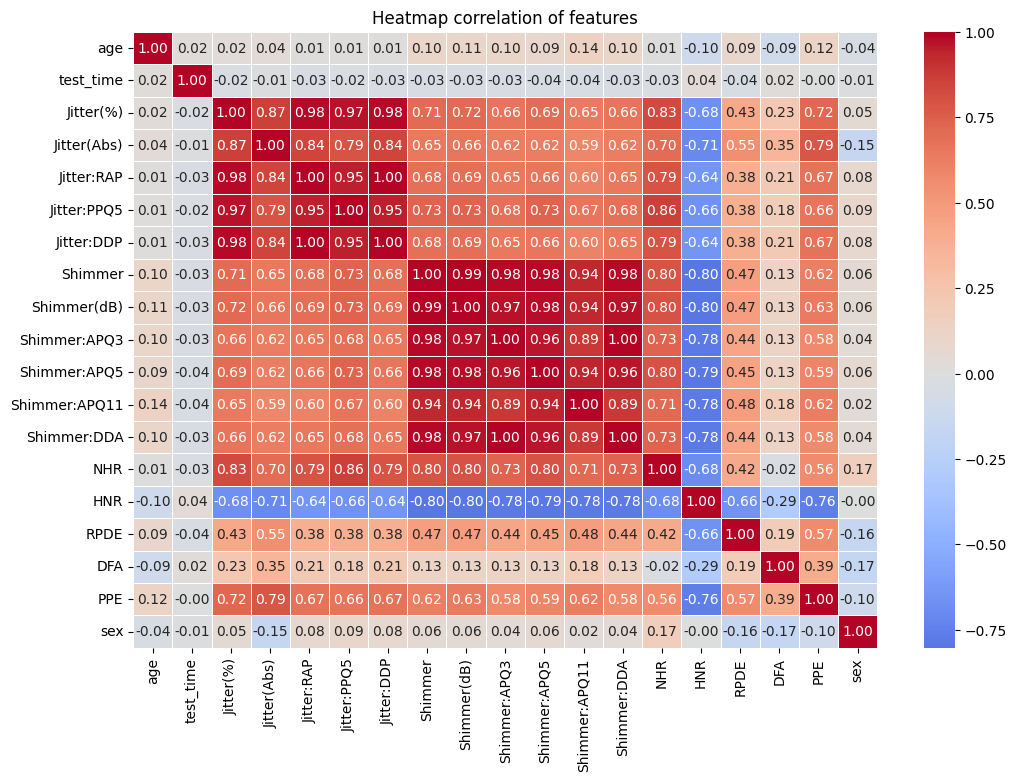

In [119]:
plt.figure(figsize=(12, 8))
# Tính toán lại correlation trên df đã xử lý (đã gộp Jitter/Shimmer và drop 'sex')
corr_matrix = df.drop(columns=['total_UPDRS', 'motor_UPDRS']).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, center = 0)
plt.title('Heatmap correlation of features')
plt.show()

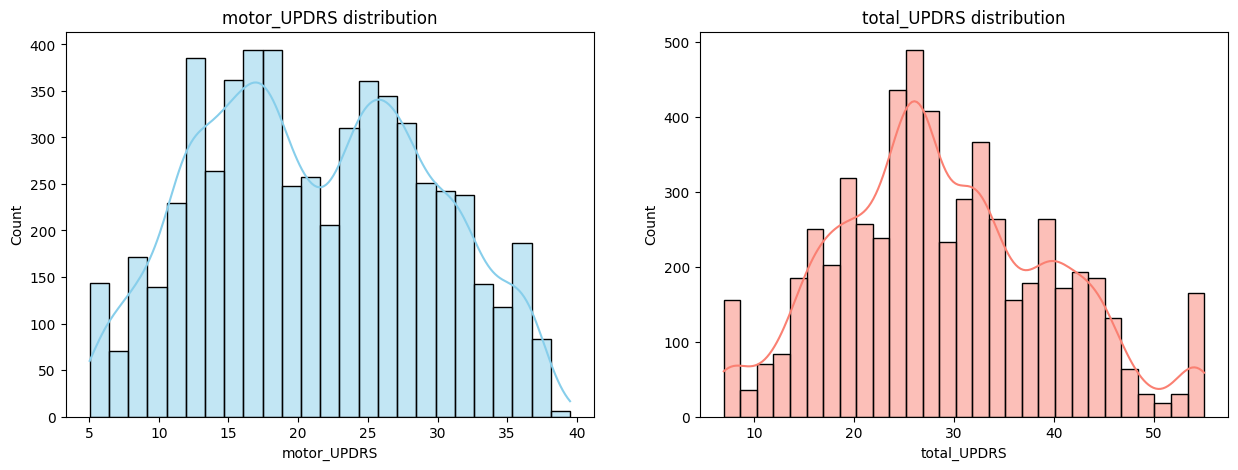

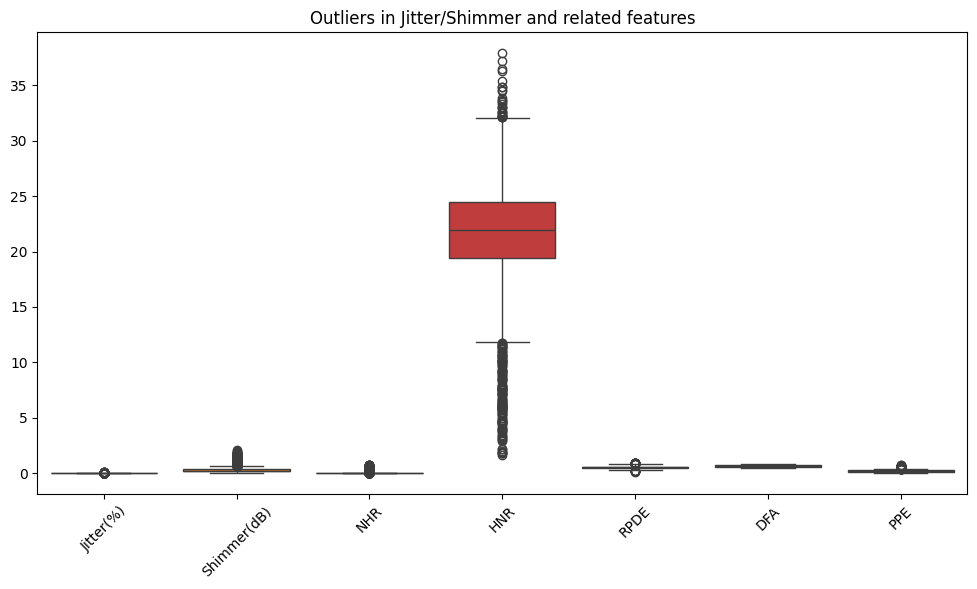

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['motor_UPDRS'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('motor_UPDRS distribution')

sns.histplot(df['total_UPDRS'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('total_UPDRS distribution')

plt.show()

plt.figure(figsize=(12, 6))
features_to_plot = ['Jitter(%)', 'Shimmer(dB)', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']
sns.boxplot(data=df[features_to_plot])
plt.title('Outliers in Jitter/Shimmer and related features')
plt.xticks(rotation=45)
plt.show()

In [121]:
print(df[['total_UPDRS', 'motor_UPDRS']].corr())

             total_UPDRS  motor_UPDRS
total_UPDRS     1.000000     0.947341
motor_UPDRS     0.947341     1.000000


In [122]:
df['Jitter(avg)'] = df[[ 'Jitter(%)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP']].mean(axis=1)
df['Shimmer(avg)'] = df[['Shimmer', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA']].mean(axis=1)
df = df.drop(columns=['Jitter(%)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP',
                      'Shimmer', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA'])

df.describe()

,age,test_time,Jitter(Abs),Shimmer(dB),NHR,HNR,RPDE,DFA,PPE,sex,motor_UPDRS,total_UPDRS,Jitter(avg),Shimmer(avg)
count,5863.000000,5863.000000,5863.000000,5863.000000,5863.000000,5863.000000,5863.000000,5863.000000,5863.000000,5863.000000,5863.000000,5863.000000,5863.000000,5863.000000
mean,64.814771,93.061538,0.000044,0.311012,0.032126,21.679527,0.541423,0.653252,0.219618,0.318438,21.289655,29.014090,0.005347,0.030061
std,8.827750,53.320896,0.000036,0.230310,0.059735,4.292521,0.101024,0.070955,0.091494,0.465910,8.133419,10.709966,0.005418,0.022670
min,36.000000,0.395830,0.000002,0.026000,0.000286,1.659000,0.151020,0.514040,0.021983,0.000000,5.037700,7.000000,0.000650,0.002788
25%,58.000000,47.335500,0.000022,0.175000,0.010953,19.404000,0.469695,0.596100,0.156385,0.000000,15.000000,21.362000,0.002971,0.016649
50%,65.000000,91.754000,0.000034,0.253000,0.018448,21.917000,0.542250,0.643550,0.205560,0.000000,20.871000,27.522000,0.004110,0.024338
75%,72.000000,138.460000,0.000053,0.365000,0.031464,24.445500,0.614045,0.711480,0.264590,1.000000,27.594000,36.400500,0.005859,0.035657
max,85.000000,215.490000,0.000446,2.107000,0.748260,37.875000,0.966080,0.865600,0.731730,1.000000,39.511000,54.992000,0.097255,0.242828


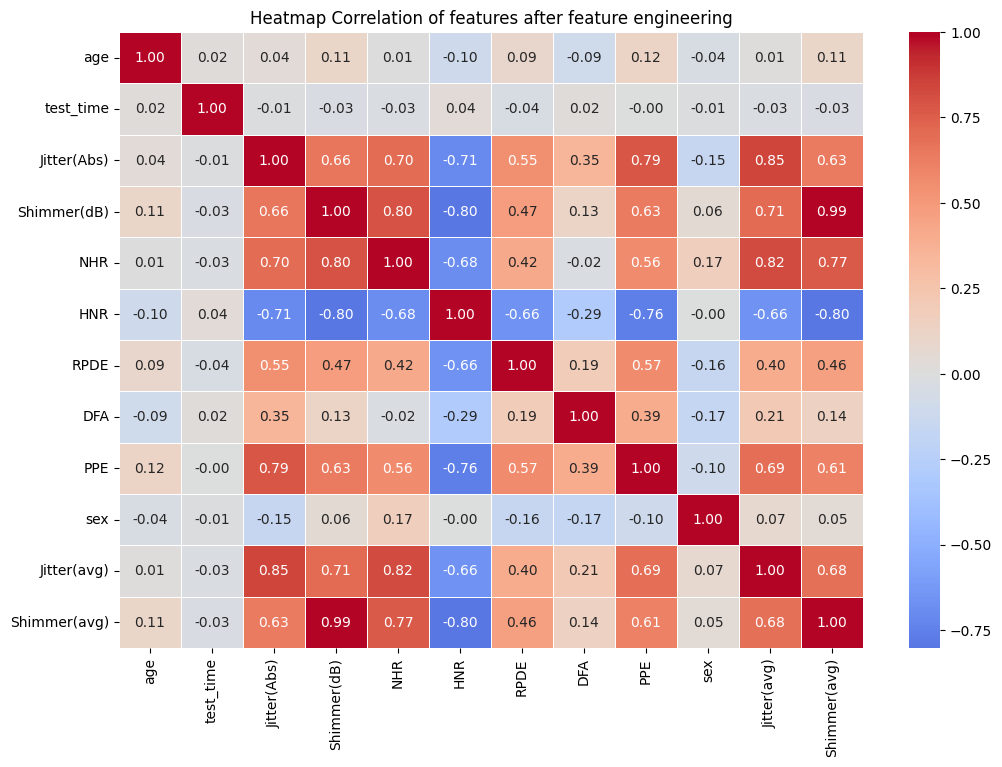

In [123]:
# Tính toán lại correlation trên df đã xử lý
plt.figure(figsize=(12, 8))
corr_matrix = df.drop(columns=['total_UPDRS', 'motor_UPDRS']).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, center = 0)
plt.title('Heatmap Correlation of features after feature engineering')
plt.show()

In [124]:
features = [col for col in df.columns if col not in target]
new_cor = df.corr()
new_corr_target = new_cor.loc[features, target]
print(new_corr_target.sort_values(by='total_UPDRS', ascending=False))

              motor_UPDRS  total_UPDRS
age              0.274469     0.310732
RPDE             0.128444     0.156854
PPE              0.163334     0.156678
Shimmer(dB)      0.110580     0.099047
Shimmer(avg)     0.100777     0.091902
test_time        0.069639     0.076343
Jitter(avg)      0.077566     0.067353
Jitter(Abs)      0.051341     0.067144
NHR              0.075273     0.061089
sex             -0.030683    -0.096307
DFA             -0.116330    -0.113508
HNR             -0.157344    -0.162303


In [125]:
df = df.drop(columns=['sex'])

- Dựa vào kết quả của hàm describe() và phân tích sự tương quan của các đặc trưng bên trên, ta thấy:
    + Các đặc trưng cùng nhóm 'Jitter' hoặc 'Shimmer' có mối tương quan rất lớn với nhau. Ngoài ra, hầu hết các đặc trưng này có vẻ như được đo trên cùng 1 scale (trừ Jitter(Abs) với Jitter và Shimmer(dB) với Shimmer). Với tương quan lớn như vậy, các đặc trưng này có thể gây ra tình trạng đa cộng tuyến, ảnh hưởng tới sự ổn định và độ chính xác của mô hình. Ở đây, ta xử lý bằng cách tạo 2 đặc trưng mới với giá trị bằng trung bình của các đặc trưng thuộc nhóm 'Jitter' và 'Shimmer'.
    + Đặc trưng 'sex' không ảnh hưởng nhiều tới việc dự đoán biến mục tiêu, vì được encode thành giá trị {0,1}, việc bao gồm đặc trưng này có thể gây nhiễu tới dự đoán của mô hình. Chúng ta sẽ drop đặc trưng này.



In [126]:
df.to_csv('preprocessed_data.csv', index=False)

*Note, các đặc trưng được đo trên scale khác nhau, cần dùng scaler trước khi train/test model

# Model implementation

Sau khi phân tích và tiền xử lý dữ liệu, ta thực hiện cài đặt, huấn luyện và đánh giá các mô hình cho bài toán Regression trên. Trong phần này, ta sử dụng những mô hình tiêu biểu cho task regression cho dữ liệu dạng bảng, bao gồm:

- Linear regression
- Random Forest
- XGBoost 
- LightGBM

Với bài toán hồi quy, các metrics để đánh giá mô hình thích hợp là **RMSE**, **MAE** và **R^{2}**. ta sẽ đánh giá độc lập kết quả dự đoán của 2 biến mục tiêu `motor_UPDRS` và `total_UPDRS`. Sau khi đánh giá và chọn ra mô hình tốt nhất, mô hình sẽ được lưu lại và sử dụng để dự đoán dữ liệu mới.


In [127]:
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from xgboost import XGBRegressor


model_lr = LinearRegression()
model_rf = RandomForestRegressor(random_state=42)
model_xgb = XGBRegressor(random_state=42)
model_lgbm = LGBMRegressor(random_state=42)
models = {
    'Linear Regression': model_lr,
    'Random Forest': model_rf,
    'XGBoost': model_xgb,
    'LightGBM': model_lgbm
}
df = pd.read_csv('preprocessed_data.csv')

targets = ['motor_UPDRS', 'total_UPDRS']
X = df.drop(columns=targets)
y = df[targets]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_motor, y_train_total = y_train['motor_UPDRS'], y_train['total_UPDRS']
y_test_motor, y_test_total = y_test['motor_UPDRS'], y_test['total_UPDRS']

In [128]:
import joblib
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

param_grids = {
    'Linear Regression': {
        'fit_intercept': [True, False]
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [5, 7, 10]
    },
    'LightGBM': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': [31, 50, 100],
        'max_depth': [5, 7, 10]
    }
}

def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

results = []
predictions = {'motor': {}, 'total': {}}

In [129]:
print("--- Model training and evaluation ---")
results = []
predictions = {'motor': {}, 'total': {}}

for name, model in models.items():
    
    model_motor = model.__class__(**model.get_params()) 
    model_motor.fit(X_train_scaled, y_train_motor)
    y_pred_motor = model_motor.predict(X_test_scaled)
    predictions['motor'][name] = y_pred_motor
    rmse_m, mae_m, r2_m = evaluate_model(y_test_motor, y_pred_motor)
    
    
    model_total = model.__class__(**model.get_params())
    model_total.fit(X_train_scaled, y_train_total)
    y_pred_total = model_total.predict(X_test_scaled)
    predictions['total'][name] = y_pred_total
    rmse_t, mae_t, r2_t = evaluate_model(y_test_total, y_pred_total)
    
    results.append({
        'Model': name,
        'Motor_RMSE': rmse_m, 'Motor_MAE': mae_m, 'Motor_R2': r2_m,
        'Total_RMSE': rmse_t, 'Total_MAE': mae_t, 'Total_R2': r2_t
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

--- Model training and evaluation ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000313 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2574
[LightGBM] [Info] Number of data points in the train set: 4690, number of used features: 11
[LightGBM] [Info] Start training from score 21.248937
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000264 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2574
[LightGBM] [Info] Number of data points in the train set: 4690, number of used features: 11
[LightGBM] [Info] Start training from score 28.992516
            Model  Motor_RMSE  Motor_MAE  Motor_R2  Total_RMSE  Total_MAE  Total_R2
Linear Regression    7.512663   6.417054  0.140320    9.785573   8.174108  0.158791
    Random Forest    1.843601   0.852375  0.948229    2.333907   1.108062  0.952148
          XGBoost    2.045

c:\Users\FPT Shop\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\FPT Shop\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [130]:
def plot_predictions(y_test, preds_dict, target_name):
    plt.figure(figsize=(15, 10))
    for i, (name, y_pred) in enumerate(preds_dict.items(), 1):
        plt.subplot(2, 2, i)
        sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='b')
        
        min_val = min(y_test.min(), y_pred.min())
        max_val = max(y_test.max(), y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
        
        plt.title(f'{name} - {target_name}')
        plt.xlabel('Actual')
        plt.ylabel('Predicted')
    plt.tight_layout()
    plt.show()

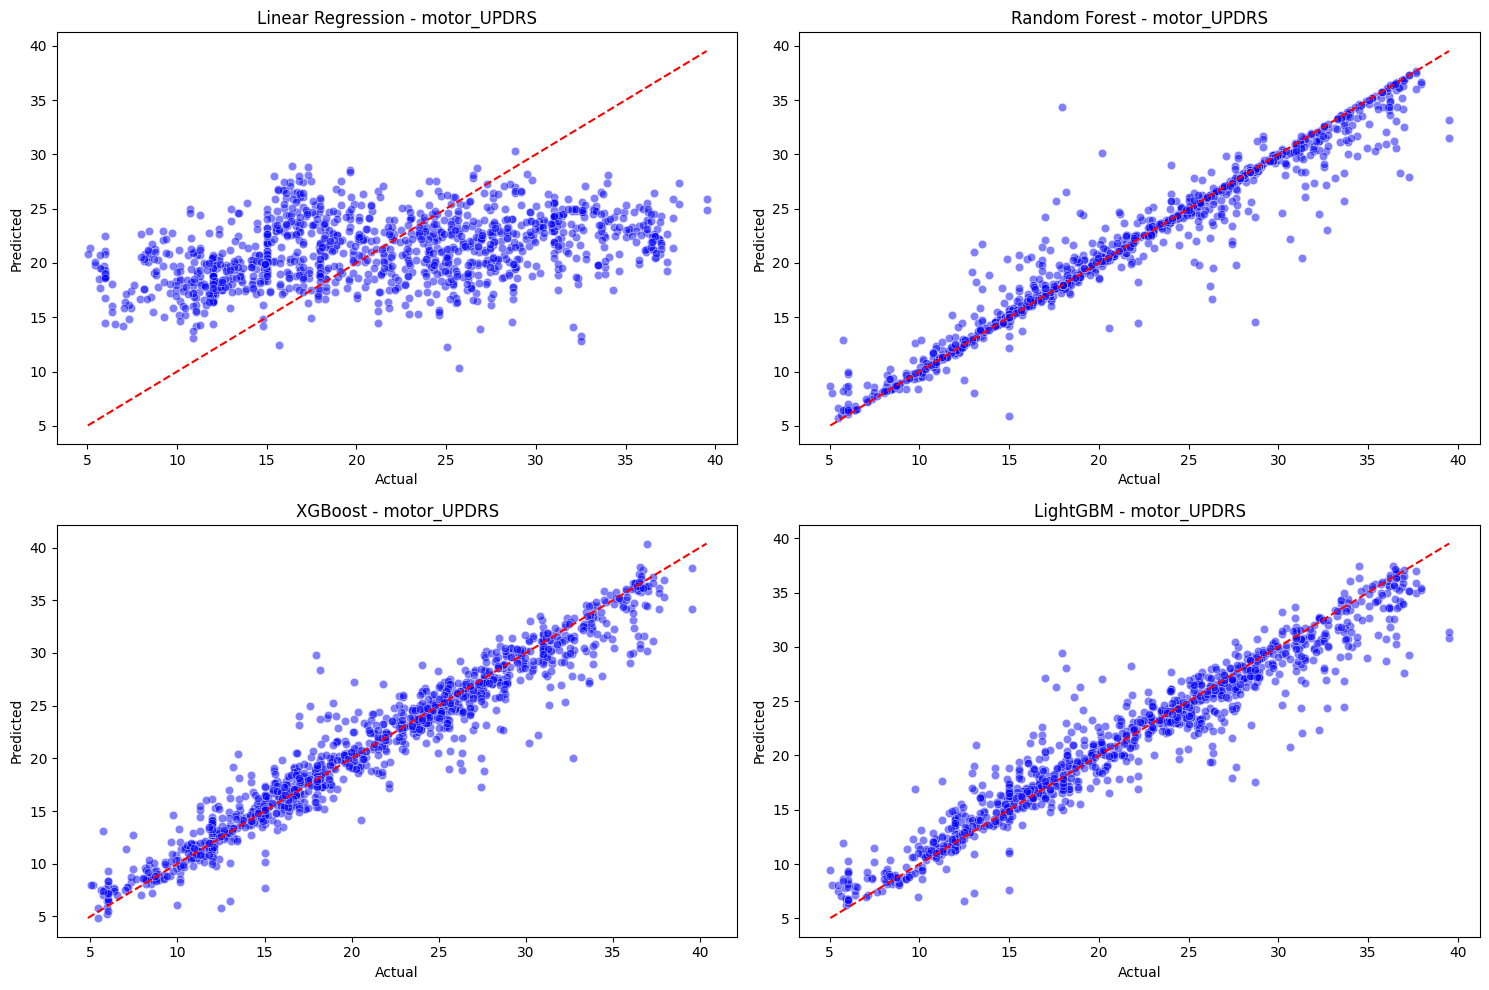

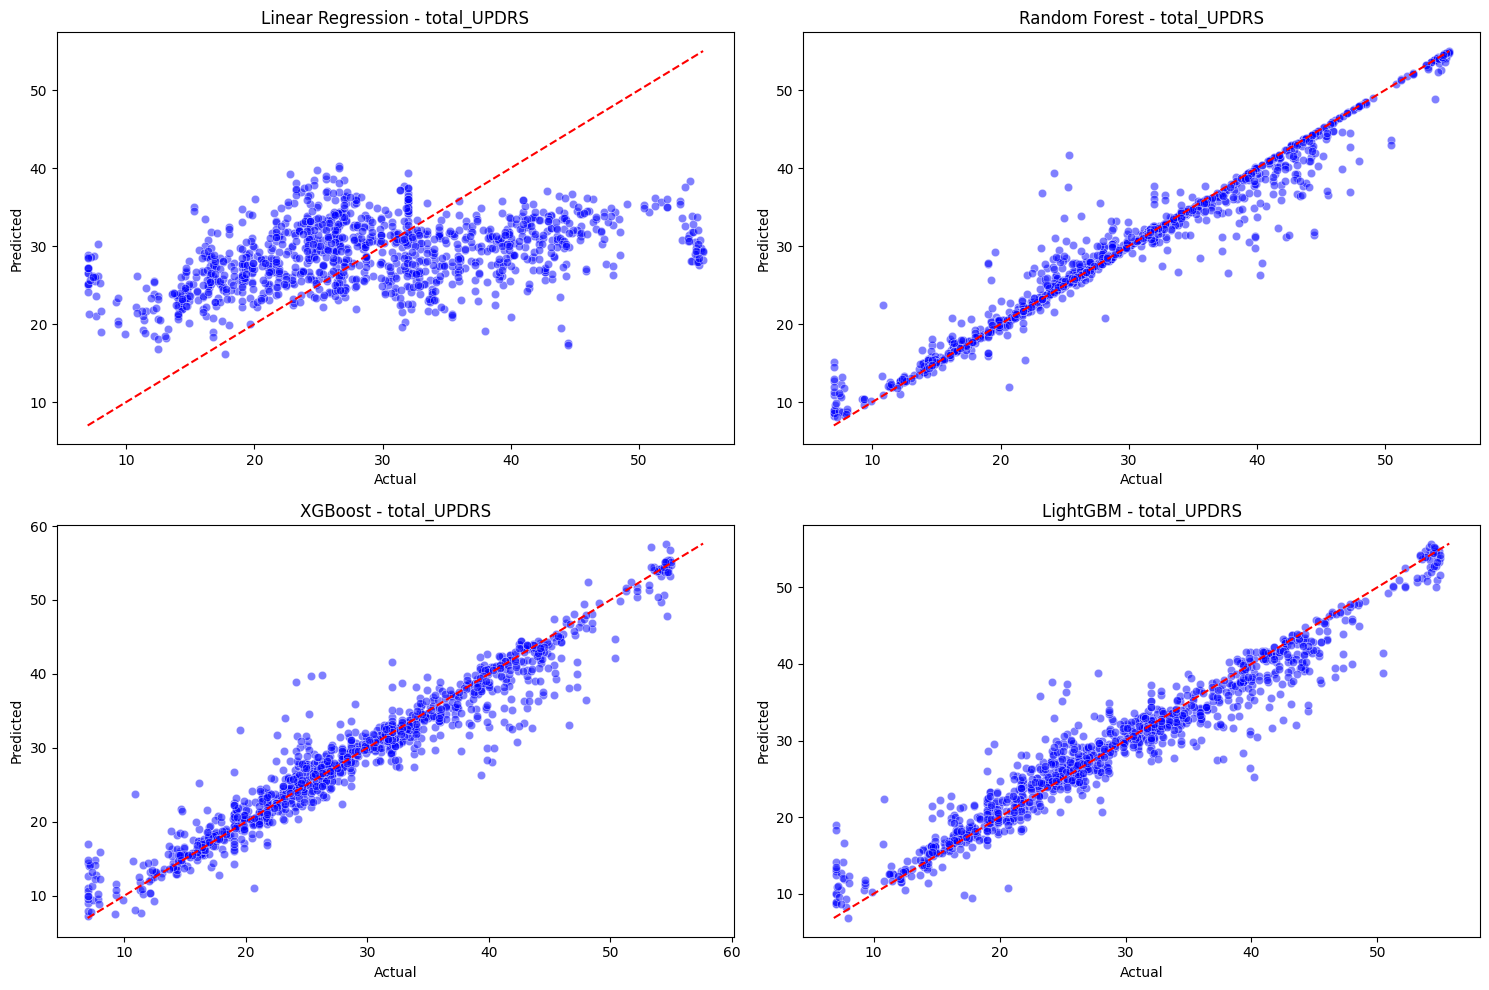

In [131]:
plot_predictions(y_test_motor, predictions['motor'], 'motor_UPDRS')
plot_predictions(y_test_total, predictions['total'], 'total_UPDRS')

In [132]:
print("\n -- Fine-tuning --")
best_motor_name = results_df.loc[results_df['Motor_RMSE'].idxmin(), 'Model']
best_total_name = results_df.loc[results_df['Total_RMSE'].idxmin(), 'Model']

print(f"Best model for motor_UPDRS: {best_motor_name}")
print(f"Best model for total_UPDRS: {best_total_name}")

def fine_tune_best_model(model_name, X_train, y_train, X_test, y_test, target_name):
    base_model = models[model_name].__class__(**models[model_name].get_params())
    param_grid = param_grids[model_name]
    
    grid_search = GridSearchCV(
        estimator=base_model, 
        param_grid=param_grid, 
        cv=5, 
        scoring='neg_mean_squared_error', 
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    
    y_pred_tuned = best_model.predict(X_test)
    rmse, mae, r2 = evaluate_model(y_test, y_pred_tuned)
    
    print(f"Best parameters: {grid_search.best_params_}")
    print("Results after tuning - RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}".format(rmse, mae, r2))
    
    pred_dict = {f'{model_name}': y_pred_tuned}
    plot_predictions(y_test, pred_dict, target_name)
    return best_model


 -- Fine-tuning --
Best model for motor_UPDRS: Random Forest
Best model for total_UPDRS: Random Forest



>> Tuning for motor_UPDRS...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Results after tuning - RMSE: 1.8001, MAE: 0.8448, R2: 0.9506


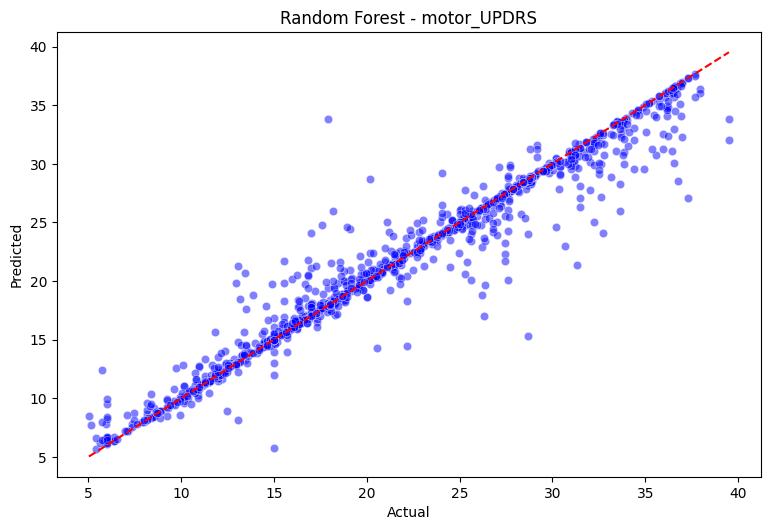


>> Tuning for total_UPDRS...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Results after tuning - RMSE: 2.2856, MAE: 1.0910, R2: 0.9541


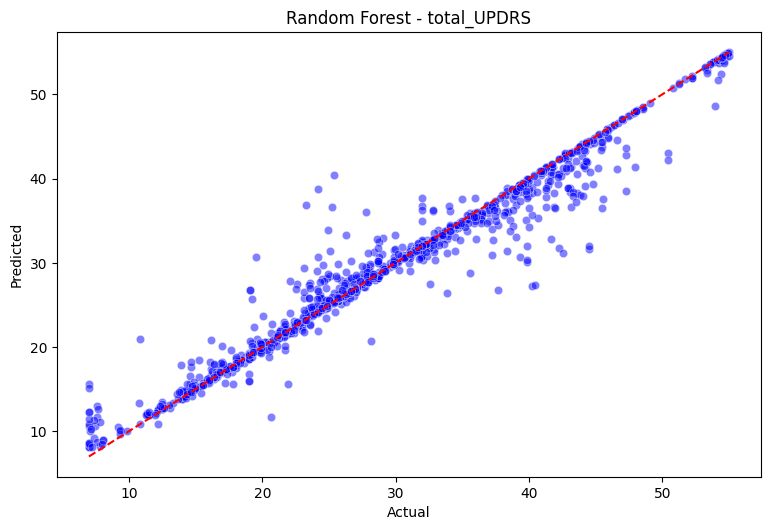


Saving model
Done


In [134]:
print("\n>> Tuning for motor_UPDRS...")
final_model_motor = fine_tune_best_model(best_motor_name, X_train_scaled, y_train_motor, X_test_scaled, y_test_motor, 'motor_UPDRS')

print("\n>> Tuning for total_UPDRS...")
final_model_total = fine_tune_best_model(best_total_name, X_train_scaled, y_train_total, X_test_scaled, y_test_total, 'total_UPDRS')

print("\nSaving model")
joblib.dump(final_model_motor, f'models/motor_updrs_model_{best_motor_name.replace(" ", "")}.pkl')
joblib.dump(final_model_total, f'models/total_updrs_model_{best_total_name.replace(" ", "")}.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
print("Done")